##Classification

In [ ]:
!pip install -q transformers datasets scikit-learn

In [ ]:
!pip install -q transformers datasets scikit-learn sentencepiece

In [ ]:
!rm -rf /kaggle/working/* #Remove kagle working if Truc want


📥 Đang đọc toàn bộ dữ liệu...

📊 BÁO CÁO PHÂN BỔ DỮ LIỆU (Tổng số: 1352 câu)
Nhãn (Category) | Số lượng (Count) | Tỷ lệ (%) 
-------------------------------------------------------
LD              | 397             | 29.36%
CH              | 290             | 21.45%
NL              | 190             | 14.05%
TD              | 177             | 13.09%
DDT             | 130             | 9.62%
THCB            | 80              | 5.92%
DT              | 68              | 5.03%
CHLT            | 20              | 1.48%


/tmp/ipykernel_22/3523384188.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")


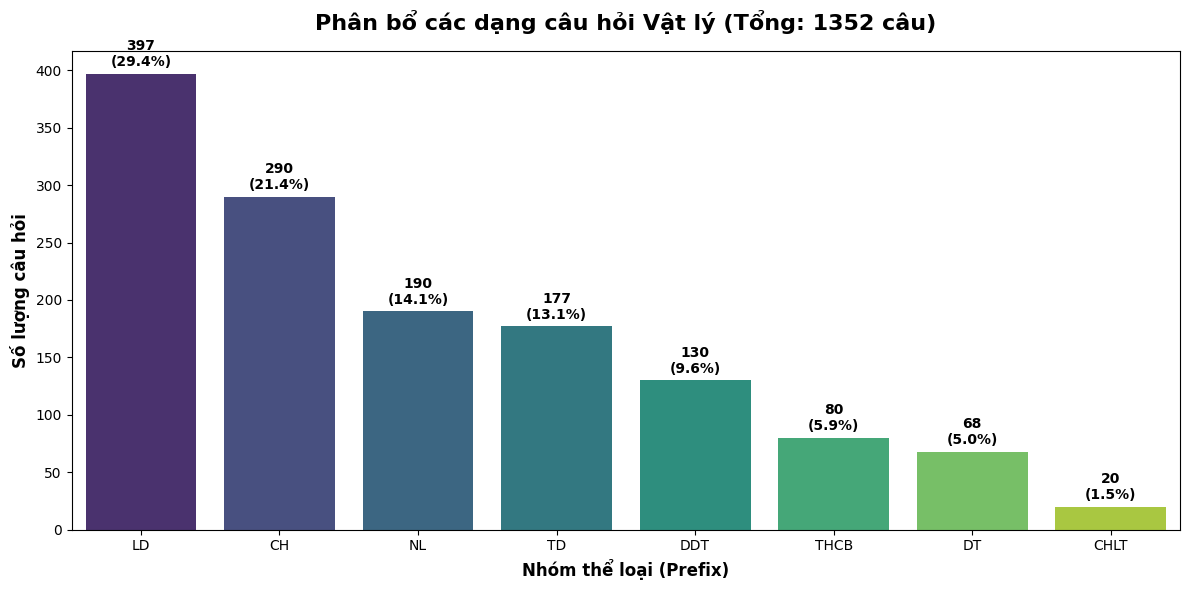

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

#Load original updated dataset from btc
INPUT_CSV = "/kaggle/input/datasets/quanghuy225/physics/Physics_Problems_Text_Only.csv"

print("📥 Đang đọc toàn bộ dữ liệu...")
try:
    df = pd.read_csv(INPUT_CSV)
except FileNotFoundError:
    print(f"❌ Không tìm thấy file {INPUT_CSV}. Vui lòng kiểm tra lại đường dẫn/tên file!")
    exit()

def extract_prefix(id_str):
    match = re.match(r'^([a-zA-Z]+)', str(id_str))
    return match.group(1).upper() if match else "UNKNOWN"

df['category'] = df['id'].apply(extract_prefix)

total_questions = len(df)
counts = df['category'].value_counts()
percentages = df['category'].value_counts(normalize=True) * 100

print("\n" + "="*55)
print(f"📊 BÁO CÁO PHÂN BỔ DỮ LIỆU (Tổng số: {total_questions} câu)")
print("="*55)
print(f"{'Nhãn (Category)':<15} | {'Số lượng (Count)':<15} | {'Tỷ lệ (%)':<10}")
print("-" * 55)

for cat in counts.index:
    print(f"{cat:<15} | {counts[cat]:<15} | {percentages[cat]:.2f}%")
print("="*55)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")

plt.title(f"Phân bổ các dạng câu hỏi Vật lý (Tổng: {total_questions} câu)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Nhóm thể loại (Prefix)", fontsize=12, fontweight='bold')
plt.ylabel("Số lượng câu hỏi", fontsize=12, fontweight='bold')

for i, v in enumerate(counts.values):
    ax.text(i, v + (max(counts.values)*0.01), f"{v}\n({percentages.iloc[i]:.1f}%)",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Căn chỉnh và hiển thị
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import re
import torch
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("📥 Đang nạp dữ liệu...")
INPUT_CSV = "/kaggle/input/datasets/quanghuy225/physics/Physics_Problems_Text_Only.csv"
df = pd.read_csv(INPUT_CSV)

def extract_prefix(id_str):
    match = re.match(r'^([a-zA-Z]+)', str(id_str))
    return match.group(1).upper() if match else "UNKNOWN"

df['label_str'] = df['id'].apply(extract_prefix)
df = df.dropna(subset=['question', 'label_str'])

labels = df['label_str'].unique().tolist()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}
df['label'] = df['label_str'].map(label2id)

# 2. handle imbalance problems
# train/test
train_df, test_df = train_test_split(df[['question', 'label']], test_size=0.2, random_state=42, stratify=df['label'])

max_size = train_df['label'].value_counts().max()

lst_balanced_dfs = []
for class_index, group in train_df.groupby('label'):
    upsampled_group = group.sample(max_size, replace=True, random_state=42)
    lst_balanced_dfs.append(upsampled_group)

balanced_train_df = pd.concat(lst_balanced_dfs)
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"⚖️ Đã cân bằng lại tập Train. Kích thước mới: {len(balanced_train_df)} câu (Các nhóm đã có số lượng bằng nhau).")

train_dataset = Dataset.from_pandas(balanced_train_df)
test_dataset = Dataset.from_pandas(test_df)

# 3. Using Scibert
print("🧠 Đang tải kiến trúc SciBERT...")
MODEL_ID = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, num_labels=len(labels), id2label=id2label, label2id=label2id
)

def tokenize_function(examples):
    return tokenizer(examples["question"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

print("🚀 Bắt đầu quá trình Fine-Tuning Cân Bằng (4 Epochs)...")
training_args = TrainingArguments(
    output_dir="/kaggle/working/scibert-balanced-router",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

final_model_path = "/kaggle/working/best_physics_router"
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)

print("\n🔍 TEST THỬ MÔ HÌNH VỚI DỮ LIỆU MẠCH ĐIỆN 1 CHIỀU...")
sample_text = "Calculate the equivalent resistance of three resistors 10 ohms each connected in parallel."
inputs = tokenizer(sample_text, return_tensors="pt").to(model.device)
with torch.no_grad():
    logits = model(**inputs).logits
predicted_class_id = logits.argmax().item()
confidence = torch.nn.functional.softmax(logits, dim=-1)[0][predicted_class_id].item()

print(f"👉 Câu test: '{sample_text}'")
print(f"🤖 Dự đoán: [{model.config.id2label[predicted_class_id]}] (Độ tự tin: {confidence*100:.2f}%)")

📥 Đang nạp dữ liệu...
⚖️ Đã cân bằng lại tập Train. Kích thước mới: 2536 câu (Các nhóm đã có số lượng bằng nhau).
🧠 Đang tải kiến trúc SciBERT...


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 TEST THỬ MÔ HÌNH VỚI DỮ LIỆU MẠCH ĐIỆN 1 CHIỀU...
👉 Câu test: 'Calculate the equivalent resistance of three resistors 10 ohms each connected in parallel.'
🤖 Dự đoán: [THCB] (Độ tự tin: 98.00%)


Combine Scibert classification with LLMs (qwen2-math:7B)



In [ ]:

!apt-get update -y && apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess
import time
subprocess.Popen(["ollama", "serve"])
time.sleep(5)

!ollama pull qwen2-math:7b

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricte

time=2026-05-18T17:29:56.458Z level=INFO source=routes.go:1802 msg="server config" env="map[CUDA_VISIBLE_DEVICES: GGML_VK_VISIBLE_DEVICES: GPU_DEVICE_ORDINAL: HIP_VISIBLE_DEVICES: HSA_OVERRIDE_GFX_VERSION: HTTPS_PROXY: HTTP_PROXY: NO_PROXY: OLLAMA_CONTEXT_LENGTH:0 OLLAMA_DEBUG:INFO OLLAMA_DEBUG_LOG_REQUESTS:false OLLAMA_EDITOR: OLLAMA_FLASH_ATTENTION:false OLLAMA_GPU_OVERHEAD:0 OLLAMA_HOST:http://127.0.0.1:11434 OLLAMA_KEEP_ALIVE:5m0s OLLAMA_KV_CACHE_TYPE: OLLAMA_LLM_LIBRARY: OLLAMA_LOAD_TIMEOUT:5m0s OLLAMA_MAX_LOADED_MODELS:0 OLLAMA_MAX_QUEUE:512 OLLAMA_MAX_TRANSFER_STREAMS:4 OLLAMA_MODELS:/root/.ollama/models OLLAMA_MULTIUSER_CACHE:false OLLAMA_NEW_ENGINE:false OLLAMA_NOHISTORY:false OLLAMA_NOPRUNE:false OLLAMA_NO_CLOUD:false OLLAMA_NUM_PARALLEL:1 OLLAMA_ORIGINS:[http://localhost https://localhost http://localhost:* https://localhost:* http://127.0.0.1 https://127.0.0.1 http://127.0.0.1:* https://127.0.0.1:* http://0.0.0.0 https://0.0.0.0 http://0.0.0.0:* https://0.0.0.0:* app://* fi

]11;?\[GIN] 2026/05/18 - 17:30:06 | 200 |       95.16µs |       127.0.0.1 | HEAD     "/"
pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠦ pulling manifest 
pulling 857e2f21d3ff:   0% ▕                  ▏ 117 KB/4.4 GB                  

time=2026-05-18T17:30:07.061Z level=INFO source=download.go:179 msg="downloading 857e2f21d3ff in 16 276 MB part(s)"


pulling manifest 
pulling 857e2f21d3ff:   0% ▕                  ▏  15 MB/4.4 GB                  pulling manifest 
pulling 857e2f21d3ff:   2% ▕                  ▏  99 MB/4.4 GB                  pulling manifest 
pulling 857e2f21d3ff:   4% ▕                  ▏ 177 MB/4.4 GB                  pulling manifest 
pulling 857e2f21d3ff:   5% ▕                  ▏ 204 MB/4.4 GB                  pulling manifest 
pulling 857e2f21d3ff:   6% ▕█                 ▏ 265 MB/4.4 GB                  pulling manifest 
pulling 857e2f21d3ff:   8% ▕█                 ▏ 336 MB/4.4 GB                  pulling manifest 
pulling 857e2f21d3ff:   9% ▕█                 ▏ 377 MB/4.4 GB                  pulling manifest 
pulling 857e2f21d3ff:  10% ▕█                 ▏ 447 MB/4.4 GB                  pulling manifest 
pulling 857e2f21d3ff:  12% ▕██                ▏ 520 MB/4.4 GB                  pulling manifest 
pulling 857e2f21d3ff:  13% ▕██                ▏ 560 MB/4.4 GB                  pulling manifest 
pulling 857e

...

pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11

time=2026-05-18T17:30:25.523Z level=INFO source=download.go:179 msg="downloading f02dd72bb242 in 1 59 B part(s)"


pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         
pulling f02dd72bb242: 100% ▕██████████████████▏   59 B                         pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         
pulling f02dd72bb242: 100% ▕██████████████████▏   59 B                         pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         
pulling f02dd72bb242: 100% ▕██████████████████▏   59 B              

time=2026-05-18T17:30:26.667Z level=INFO source=download.go:179 msg="downloading cf595c6f4840 in 1 485 B part(s)"


pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         
pulling f02dd72bb242: 100% ▕██████████████████▏   59 B                         
pulling cf595c6f4840: 100% ▕██████████████████▏  485 B                         pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         
pulling f02dd72bb242: 100% ▕██████████████████▏   59 B                         
pulling cf595c6f4840: 100% ▕██████████████████▏  485 B                         pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B              

In [ ]:
import torch
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from openai import OpenAI

client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama") #Change localhost:xxxxx to your own number
MODEL_NAME = "qwen2-math:7b"
ROUTER_PATH = "/kaggle/working/best_physics_router" #This file will be extracted after running the code above

# Dictionary for different types of question
PREFIX_MAP = {
    "CH": "RLC Alternating Current (AC) circuits driven by an external AC power source, Resonance, Impedance, AC frequency/omega. (CRITICAL: Excludes free LC loops without an external AC source. If the circuit is just an Inductor + Capacitor closed together, it is NOT CH).",
    "NL": "Ideal LC Oscillation circuits, free electromagnetic oscillations, energy transformation between L and C. (CRITICAL: Even if the question asks for 'alternating current' or frequency generated internally by the L and C loop, it MUST be classified as NL, NOT CH).",
    "LD": "Electrostatics, Point charges, Coulomb's Law, Electric field strength/vectors, Electric potential energy of stationary charges. (Pure charges without plates/capacitors).",
    "TD": "Capacitors and Capacitance. Parallel-plate structures, Dielectric constants, Energy stored in a capacitor, Charge on plates. (Focus is on the capacitor itself, not the full DC network).",
    "THCB": "Error Propagation, Basic metrology, Calculating absolute errors (delta) or relative errors (%) in physics measurements and formulas.",
    "DT": "Direct Current (DC) circuits. Resistor networks, Ohm's law, Series/Parallel resistors, internal resistance of batteries, DC power dissipation. (If it has a constant DC voltage source and resistors, it's DT)."
}

print("🧠 Đang nạp Router nhỏ vào VRAM...")
tokenizer = AutoTokenizer.from_pretrained(ROUTER_PATH)
router_model = AutoModelForSequenceClassification.from_pretrained(ROUTER_PATH)
router_model.eval()

# Using Qwen2 to handle questions with low confidence
def llm_validator_agent(question):
    """Bắt Qwen2-Math phải lập luận từng bước trước khi chốt nhãn nhằm bẻ gãy Keyword Bias"""
    categories_str = ""
    for key, desc in PREFIX_MAP.items():
        categories_str += f"- [{key}]: {desc}\n"

    sys_prompt = (
        "You are an expert Physics Classifier (Agent Validator).\n"
        "A smaller keyword-based model failed to classify a physics question. Your job is to analyze it carefully.\n"
        "Here are the 6 valid categories and definitions:\n"
        f"{categories_str}\n"
        "CRITICAL INSTRUCTIONS:\n"
        "1. Think step-by-step. Analyze the core physical phenomenon described in the question.\n"
        "2. Identify any distractor keywords and explain why they might be misleading.\n"
        "3. At the very end of your response, output the final category key inside this exact format: [FINAL_LABEL: KEY] (e.g., [FINAL_LABEL: NL])."
    )

    try:
        res = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": sys_prompt},
                {"role": "user", "content": f"QUESTION:\n{question}"}
            ],
            temperature=0.0
        )
        llm_response = res.choices[0].message.content

        print(f"\n   🧠 [Qwen2-Math Reasoning Log]:\n{llm_response}\n")

        match = re.search(r'\[FINAL_LABEL:\s*([A-Z]+)\]', llm_response)
        if match:
            final_key = match.group(1).strip()
            if final_key in PREFIX_MAP.keys():
                return final_key
        return "UNKNOWN"
    except Exception as e:
        return "ERROR_API"

# PIPELINE
def hybrid_classify(question, threshold=85.0): #Sciber with 85% confidence -> Pick, lower than 85% -> Kick
    inputs = tokenizer(question, return_tensors="pt", padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(router_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = router_model(**inputs).logits

    probs = torch.nn.functional.softmax(logits, dim=-1)[0]
    top_1_id = probs.argmax().item()
    t1_label = router_model.config.id2label[top_1_id]

    if t1_label == 'DDT':
        t1_label = 'DT'
    elif t1_label == 'CHLT':
        t1_label = 'CH'

    t1_conf = probs[top_1_id].item() * 100

    print(f"   ↳ [Router Nhỏ] Dự đoán: {t1_label} ({t1_conf:.1f}%)")

    if t1_conf >= threshold and t1_label in PREFIX_MAP:
        print(f"   ✅ ĐỘ TỰ TIN CAO -> CHỐT NHÃN (Fast Path): {t1_label}")
        return t1_label
    else:
        print(f"   ↳ ⚠️ Tự tin thấp (< {threshold}%) hoặc nhãn không chuẩn! Chuyển giao Hội đồng xét xử Qwen2-Math...")
        final_label = llm_validator_agent(question)
        print(f"   🎯 KẾT LUẬN CUỐI CÙNG: KHỚP NHÃN [{final_label}]")
        return final_label

# Test
if __name__ == "__main__":
    validation_suite = [
        {
            "id": "LD",
            "q": "Three charges q1 = q2 = 2.68 × 10^-6 C and q3 = 1.20 × 10^-6 C are placed at the three vertices of an equilateral triangle with side length 6.46 cm. Calculate the net electric field at the position of q3. Give your answer rounded to two decimal places.",
            "target": "LD",
            "reason" : "no"
        }
    ]

    print("="*80)

    success_count = 0
    for i, case in enumerate(validation_suite):
        print(f"\n[CÂU HỎI SỐ {i+1}] ID: {case['id']}")
        print(f"📝 Nội dung: {case['q']}")
        print(f"🎯 Nhãn đúng lý thuyết: {case['target']} | Ý đồ bẫy: {case['reason']}")

        final_decision = hybrid_classify(case['q'], threshold=85.0)

        if final_decision == case['target']:
            print("💯 KẾT QUẢ: ĐÚNG CHUẨN!")
            success_count += 1
        else:
            print("❌ KẾT QUẢ: BỊ SAI BẪY!")
        print("-" * 80)

    print(f"\n📊 KẾT QUẢ ĐÁNH GIÁ PIPELINE: ĐÚNG {success_count}/{len(validation_suite)} CÂU HỎI BẪY!")

🧠 Đang nạp Router nhỏ vào VRAM...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


[CÂU HỎI KHIỂU CHIẾN SỐ 1] ID: LD
📝 Nội dung: Three charges q1 = q2 = 2.68 × 10^-6 C and q3 = 1.20 × 10^-6 C are placed at the three vertices of an equilateral triangle with side length 6.46 cm. Calculate the net electric field at the position of q3. Give your answer rounded to two decimal places.
🎯 Nhãn đúng lý thuyết: LD | Ý đồ bẫy: no
   ↳ [Router Nhỏ] Dự đoán: LD (99.1%)
   ✅ ĐỘ TỰ TIN CAO -> CHỐT NHÃN (Fast Path): LD
💯 KẾT QUẢ: ĐÚNG CHUẨN!
--------------------------------------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ PIPELINE: ĐÚNG 1/1 CÂU HỎI BẪY!


In [ ]:
# Check on test dataset, how many questions did the model do wrong?
router_model.eval()
real_errors = []

print("🔍 Đang rà soát tập dữ liệu Test thực tế...")
for index, row in test_df.iterrows():
    q = row['question']
    true_label = id2label[row['label']]

    inputs = tokenizer(q, return_tensors="pt", padding=True, truncation=True, max_length=128).to(router_model.device)
    with torch.no_grad():
        logits = router_model(**inputs).logits

    probs = torch.nn.functional.softmax(logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    pred_label = router_model.config.id2label[pred_id]
    conf = probs[pred_id].item() * 100

    if pred_label != true_label and conf >= 85.0:
        real_errors.append({
            "question": q,
            "true": true_label,
            "pred": pred_label,
            "conf": conf
        })

print(f"📊 Tìm thấy {len(real_errors)} câu thực tế bị lỗi 'Tự tin thái quá' trong tập Test!")
if len(real_errors) > 0:
    print("\n👇 Đây là 5 câu thực tế điển hình nhất từ dataset của bạn:")
    for item in real_errors[:5]:
        print(f"📝 Đề bài: {item['question']}")
        print(f"🎯 Nhãn gốc: {item['true']} | 🤖 DeBERTa đoán bừa thành: {item['pred']} ({item['conf']:.1f}%)")
        print("-" * 50)

🔍 Đang rà soát tập dữ liệu Test thực tế...
📊 Tìm thấy 8 câu thực tế bị lỗi 'Tự tin thái quá' trong tập Test!

👇 Đây là 5 câu thực tế điển hình nhất từ dataset của bạn:
📝 Đề bài: A capacitor has a constant capacitance. If the voltage increases by 3 times, by what factor will the stored energy increase?
🎯 Nhãn gốc: TD | 🤖 DeBERTa đoán bừa thành: NL (98.1%)
--------------------------------------------------
📝 Đề bài: A resonant RLC circuit has R = 10 Ω and U = 100 V. Calculate the effective current.
🎯 Nhãn gốc: DDT | 🤖 DeBERTa đoán bừa thành: CH (98.6%)
--------------------------------------------------
📝 Đề bài: In a resonant circuit, given a resistance R = 8 Ω and a voltage U = 64 V, what is the power consumed?
🎯 Nhãn gốc: DDT | 🤖 DeBERTa đoán bừa thành: CH (99.1%)
--------------------------------------------------
📝 Đề bài: Two charges q₁ = +4 × 10^-9 C and q₂ = –4 × 10^-9 C are placed at points A and B, separated by 2 cm. Calculate the magnitude of the electric field strength at point

Actually, the model didnt do anything wrong, there was some errors from original dataset envolving in classifying types of questions.

Rearrange questions by its prefix

In [ ]:
import pandas as pd
import re

INPUT_DATASET = "/kaggle/input/datasets/quanghuy225/physics/Physics_Problems_Text_Only.csv"
OUTPUT_SORTED = "/kaggle/working/physics_problems_sorted_clean.csv"

df = pd.read_csv(INPUT_DATASET)

def extract_prefix(id_str):
    match = re.match(r'^([a-zA-Z]+)', str(id_str))
    return match.group(1).upper() if match else "UNKNOWN"

df['prefix'] = df['id'].apply(extract_prefix)

VALID_PREFIXES = ['CH', 'NL', 'LD', 'TD', 'THCB', 'DT', 'DDT', 'CHLT']
df_clean = df[df['prefix'].isin(VALID_PREFIXES)].copy()

df_sorted = df_clean.sort_values(by=['prefix', 'id']).reset_index(drop=True)

df_sorted.to_csv(OUTPUT_SORTED, index=False)

print(f"Tổng số câu giữ lại: {len(df_sorted)}")
print(df_sorted['prefix'].value_counts())

Tổng số câu giữ lại: 1352
prefix
LD      397
CH      290
NL      190
TD      177
DDT     130
THCB     80
DT       68
CHLT     20
Name: count, dtype: int64


##Examine how Qwen (qwen2-math:7B) do physical problems

From each type of question. I take random 20 samples, and let Qwen try to answer these questions.

In [ ]:
import pandas as pd
import numpy as np
import re

INPUT_DATASET = "/kaggle/input/datasets/quanghuy225/physics/Physics_Problems_Text_Only.csv"
OUTPUT_MAX_COVERAGE = "/kaggle/working/stratified_160_samples.csv"

df = pd.read_csv(INPUT_DATASET)

def extract_prefix(id_str):
    match = re.match(r'^([a-zA-Z]+)', str(id_str))
    return match.group(1).upper() if match else "UNKNOWN"

df['prefix'] = df['id'].apply(extract_prefix)

VALID_PREFIXES = ['CH', 'NL', 'LD', 'TD', 'THCB', 'DT', 'DDT', 'CHLT']
df_clean = df[df['prefix'].isin(VALID_PREFIXES)].copy()

#Arrage questions with its prefix
df_clean = df_clean.sort_values(by=['prefix', 'id']).reset_index(drop=True)

# Systematic Chunk
SAMPLES_PER_CLASS = 20
golden_samples = []

for prefix, group in df_clean.groupby('prefix'):
    group = group.reset_index(drop=True)
    n_items = len(group)
    if n_items <= SAMPLES_PER_CLASS:
        golden_samples.append(group)
    else:
        chunks = np.array_split(group, SAMPLES_PER_CLASS)
        for chunk in chunks:
            golden_samples.append(chunk.sample(n=1, random_state=42))

final_sampled_df = pd.concat(golden_samples).reset_index(drop=True)
final_sampled_df.to_csv(OUTPUT_MAX_COVERAGE, index=False)

print("\n" + "="*60)
print("✅ ĐÃ LẤY MẪU THÀNH CÔNG BẰNG THUẬT TOÁN CHIA KHÚC!")
print("="*60)
print(f"Tổng số câu đại diện: {len(final_sampled_df)}")
print("\nSố lượng câu phủ kín từng dạng:")
print(final_sampled_df['prefix'].value_counts(sort=False))
print("-" * 60)
print(f"💾 File lưu tại: {OUTPUT_MAX_COVERAGE}")
print("Bây giờ bạn hoàn toàn yên tâm 100% không bị sót bất kỳ dạng bài nhỏ nào!")


✅ ĐÃ LẤY MẪU THÀNH CÔNG BẰNG THUẬT TOÁN CHIA KHÚC!
Tổng số câu đại diện: 160

Số lượng câu phủ kín từng dạng:
prefix
CH      20
CHLT    20
DDT     20
DT      20
LD      20
NL      20
TD      20
THCB    20
Name: count, dtype: int64
------------------------------------------------------------
💾 File lưu tại: /kaggle/working/stratified_160_samples.csv
Bây giờ bạn hoàn toàn yên tâm 100% không bị sót bất kỳ dạng bài nhỏ nào!


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Let model working on 160 good samples

In [ ]:
import subprocess
import time

print("🔌 Đang khởi động máy chủ Ollama ngầm...")
# Turn Ollama on, I want to use Qwen2-Math:7B
subprocess.Popen(["ollama", "serve"])

time.sleep(5)
print("✅ Máy chủ đã bật!")

print("📥 Đang kiểm tra và nạp mô hình Qwen2-Math:7b...")
!ollama pull qwen2-math:7b
print("🚀 TẤT CẢ ĐÃ SẴN SÀNG!")

🔌 Đang khởi động máy chủ Ollama ngầm...


Error: listen tcp 127.0.0.1:11434: bind: address already in use


✅ Máy chủ đã bật!
📥 Đang kiểm tra và nạp mô hình Qwen2-Math:7b...
]11;?\[GIN] 2026/05/18 - 17:31:18 | 200 |      37.186µs |       127.0.0.1 | HEAD     "/"
pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ [GIN] 2026/05/18 - 17:31:18 | 200 |  345.123281ms |       127.0.0.1 | POST     "/api/pull"
pulling manifest 
pulling 857e2f21d3ff: 100% ▕██████████████████▏ 4.4 GB                         
pulling 029b87c88d24: 100% ▕██████████████████▏  102 B                         
pulling 43070e2d4e53: 100% ▕██████████████████▏  11 KB                         
pulling f02dd72bb242: 100% ▕██████████████████▏   59 B                         
pulling cf595c6f4840: 100% ▕██████████████████▏  485 B                         
verifying sha256 digest 
writing manifest 
success 
🚀 TẤT CẢ ĐÃ SẴN SÀNG!


The code below is the first shot to 160 samples, so there will be some errors in the output. However, we can explore how Qwen2-Math:7b, What is the problems? How can we improve the model?...

In [ ]:
import pandas as pd
import re
import math
import signal
from openai import OpenAI
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# Configuration
client = OpenAI(
    base_url="http://localhost:11434/v1", #Remember to change 11434 to your own numberic API
    api_key="ollama",
    timeout=45.0
)
MODEL_NAME = "qwen2-math:7b"

INPUT_FILE = "stratified_160_samples.csv"
OUTPUT_GOLDEN = "golden_rag_database_final.csv"
OUTPUT_DEBUG = "debug_evaluation_log_final.csv"

MAX_CORRECTION_ATTEMPTS = 2  # Number of time I allow Qwen2 to fix by itself

# Clean dataset
def clean_btc_answer(ans):
    ans_str = str(ans).strip()
    ans_str = ans_str.replace('× 10^', 'e').replace('×10^', 'e').replace('x 10^', 'e')
    ans_str = ans_str.replace('× 10⁻', 'e-').replace('×10⁻', 'e-')
    ans_str = ans_str.replace(' . 10^{-', 'e-').replace('. 10^{-', 'e-').replace('}', '')
    superscripts = {'⁰':'0', '¹':'1', '²':'2', '³':'3', '⁴':'4', '⁵':'5', '⁶':'6', '⁷':'7', '⁸':'8', '⁹':'9', '⁻':'-'}
    for k, v in superscripts.items():
        ans_str = ans_str.replace(k, v)
    return ans_str

# COT, first agent
def generate_initial_code(question, expected_unit):
    tick = chr(96)
    marker = tick * 3

    # PROMPT
    sys_prompt = (
        "You are an expert Physics Python Developer.\n"
        "RULES:\n"
        "1. NO SPACES in variable names (use 'E_net', NOT 'E Net').\n"
        "2. NO UNICODE MATH (use '**2', NOT '²').\n"
        "3. VIETNAM CONVENTION: Always assume gravity g = 10, pi**2 = 10, k = 9e9 unless stated otherwise.\n"
        "4. CHAIN OF THOUGHT: You MUST write your step-by-step reasoning in Python comments (#) BEFORE writing the calculation code.\n"
        f"5. The final answer MUST be mathematically converted to this exact unit: [{expected_unit}].\n"
        "6. CRITICAL: Store the final numerical value in a variable named exactly 'final_result'.\n"
        f"Output ONLY executable Python code inside {marker}python and {marker} block."
    )

    try:
        res = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": sys_prompt},
                {"role": "user", "content": f"PROBLEM:\n{question}"}
            ],
            temperature=0.0,
            max_tokens=600
        )
        content = res.choices[0].message.content
        pattern = rf"{marker}(?:python)?\s*(.*?)\s*{marker}"
        match = re.search(pattern, content, re.DOTALL | re.IGNORECASE)

        if not match:
            return f"raise Exception('FORMAT ERROR: You wrote text instead of Python code. You MUST enclose code in {marker}python block!')"

        return match.group(1).strip()
    except Exception as e:
        return f"raise Exception('API Error: {str(e)}')"

# Critic, second agent
def self_correct_code(question, faulty_code, error_message):
    tick = chr(96)
    marker = tick * 3

    sys_prompt = (
        "You are a Senior Python Code Reviewer fixing a Runtime/Syntax Error in a physics script.\n"
        "CRITICAL RULES:\n"
        "1. Fix variable names with spaces.\n"
        "2. Fix illegal or unicode characters.\n"
        "3. Ensure all variables used in formulas are properly defined beforehand.\n"
        "4. CRITICAL: The output variable MUST be exactly named 'final_result'.\n"
        f"Output ONLY the corrected code inside {marker}python and {marker} block. Do not explain."
    )

    user_prompt = (
        f"PROBLEM:\n{question}\n\n"
        f"FAULTY CODE:\n```python\n{faulty_code}\n```\n\n"
        f"COMPILER ERROR MESSAGE:\n{error_message}\n\n"
        "Please rewrite the fixed code now."
    )

    try:
        res = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": sys_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.0,
            max_tokens=600
        )
        content = res.choices[0].message.content
        pattern = rf"{marker}(?:python)?\s*(.*?)\s*{marker}"
        match = re.search(pattern, content, re.DOTALL | re.IGNORECASE)

        if not match:
            return f"raise Exception('FORMAT ERROR: You wrote text instead of Python code. You MUST enclose code in {marker}python block!')"

        return match.group(1).strip()
    except Exception as e:
        return faulty_code

# Error handling
class TimeoutException(Exception): pass

def timeout_handler(signum, frame):
    raise TimeoutException("Code execution took too long!")

def execute_sandbox(code_str):
    if not code_str:
        return None, "No code generated"

    def mock_input(*args, **kwargs):
        raise Exception("Usage of input() is banned to prevent deadlock.")

    local_env = {
        'math': math, 'pi': math.pi, 'sqrt': math.sqrt,
        'k': 9e9, 'e': 1.6e-19, 'c': 3e8, 'g': 10.0, # Chốt cứng g=10 trong môi trường
        'input': mock_input
    }

    try:
        signal.signal(signal.SIGALRM, timeout_handler)
        signal.alarm(5)

        exec(code_str, globals(), local_env)
        signal.alarm(0)

        if 'final_result' not in local_env:
            return None, "CRITICAL ERROR: The variable 'final_result' is missing. You MUST assign the final calculated value to 'final_result'."

        return local_env.get('final_result', None), None

    except TimeoutException:
        return None, "Execution Error: Time limit exceeded (Infinite loop detected)"
    except Exception as e:
        signal.alarm(0)
        return None, f"Execution Error: {str(e)}"

# Chech on ground truth (original data)
def check_correctness(model_ans, btc_ans):
    if model_ans is None:
        return False
    btc_clean = clean_btc_answer(btc_ans)
    try:
        return math.isclose(float(model_ans), float(btc_clean), rel_tol=1e-2)
    except (ValueError, TypeError):
        return str(model_ans).strip().lower() == str(btc_clean).strip().lower()

# Pipeline
print("📥 Đang tải dữ liệu: 160 câu...")
df = pd.read_csv(INPUT_FILE).dropna(subset=['question', 'answer'])

golden_records = []
debug_records = []

print(f"🚀 Khởi động Ultimate Pipeline (Chain of Thought + VN Physics Rules)...\n")

for index, row in tqdm(df.iterrows(), total=len(df), desc="Lò luyện Agent"):
    q = row['question']
    btc_ans = row['answer']
    unit = str(row['unit']) if pd.notna(row['unit']) else "standard SI unit"

    code = generate_initial_code(q, unit)

    attempts = 0
    model_ans, err_msg = execute_sandbox(code)

    while err_msg is not None and attempts < MAX_CORRECTION_ATTEMPTS:
        attempts += 1
        code = self_correct_code(q, code, err_msg)
        model_ans, err_msg = execute_sandbox(code)

    is_correct = check_correctness(model_ans, btc_ans)

    debug_records.append({
        "id": row['id'], "prefix": row['prefix'], "question": q, "target_unit": unit,
        "btc_answer": btc_ans, "model_calculated_answer": model_ans,
        "is_correct": is_correct, "error_message": err_msg if err_msg else "Success Execution",
        "attempts_needed": attempts, "generated_code": code
    })

    if is_correct:
        golden_records.append({
            "id": row['id'], "prefix": row['prefix'], "question": q,
            "golden_code": code, "answer": btc_ans
        })

# Result
pd.DataFrame(debug_records).to_csv(OUTPUT_DEBUG, index=False)
golden_df = pd.DataFrame(golden_records)

if len(golden_df) > 0:
    print("\n" + "="*65)
    print(f"🎉 HOÀN TẤT! Thu hoạch được {len(golden_df)}/{len(df)} CÂU VÀNG!")
    print("="*65)
    golden_df.to_csv(OUTPUT_GOLDEN, index=False)
    print(golden_df['prefix'].value_counts(sort=False).to_string())
    print("="*65)
else:
    print("\n⚠️ THẤT BẠI: Vẫn không lấy được câu vàng nào. Hãy kiểm tra file debug_evaluation_log_final.csv!")

📥 Đang tải dữ liệu: 160 câu...
🚀 Khởi động Ultimate Pipeline (Chain of Thought + VN Physics Rules)...



Lò luyện Agent:   0%|          | 0/160 [00:00<?, ?it/s]time=2026-05-18T17:31:20.022Z level=INFO source=server.go:433 msg="starting runner" cmd="/usr/local/bin/ollama runner --ollama-engine --port 39431"
llama_model_loader: loaded meta data with 28 key-value pairs and 339 tensors from /root/.ollama/models/blobs/sha256-857e2f21d3ffef28100d6799ae3fc8d5c9125d5434a041b6a741dd123ba2b0fa (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen2
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen2 Math 7B Instruct
llama_model_loader: - kv   3:                           general.finetune str              = Instruct
llama_model_loader: - kv   4:                           general.basename str   

[GIN] 2026/05/18 - 17:32:05 | 499 | 45.296166564s |       127.0.0.1 | POST     "/v1/chat/completions"


time=2026-05-18T17:32:05.490Z level=INFO source=server.go:433 msg="starting runner" cmd="/usr/local/bin/ollama runner --ollama-engine --port 42181"
llama_model_loader: loaded meta data with 28 key-value pairs and 339 tensors from /root/.ollama/models/blobs/sha256-857e2f21d3ffef28100d6799ae3fc8d5c9125d5434a041b6a741dd123ba2b0fa (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen2
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen2 Math 7B Instruct
llama_model_loader: - kv   3:                           general.finetune str              = Instruct
llama_model_loader: - kv   4:                           general.basename str              = Qwen2-Math
llama_model_loader: - kv   5:  

[GIN] 2026/05/18 - 17:32:50 | 500 | 45.017642253s |       127.0.0.1 | POST     "/v1/chat/completions"


...

[GIN] 2026/05/18 - 18:18:03 | 200 |  3.294390777s |       127.0.0.1 | POST     "/v1/chat/completions"
0.4166666666666667
[GIN] 2026/05/18 - 18:18:16 | 200 | 12.428587141s |       127.0.0.1 | POST     "/v1/chat/completions"
[GIN] 2026/05/18 - 18:18:18 | 200 |  2.856126833s |       127.0.0.1 | POST     "/v1/chat/completions"


Lò luyện Agent:  99%|█████████▉| 159/160 [47:02<00:14, 14.38s/it]

[GIN] 2026/05/18 - 18:18:21 | 200 |  2.656763169s |       127.0.0.1 | POST     "/v1/chat/completions"
[GIN] 2026/05/18 - 18:18:39 | 200 | 18.132344632s |       127.0.0.1 | POST     "/v1/chat/completions"


Lò luyện Agent: 100%|██████████| 160/160 [47:24<00:00, 17.78s/it]

[GIN] 2026/05/18 - 18:18:43 | 200 |  3.810147799s |       127.0.0.1 | POST     "/v1/chat/completions"

🎉 HOÀN TẤT! Thu hoạch được 55/160 CÂU VÀNG!
prefix
CH      10
DDT     12
DT       3
LD       2
NL      14
TD       8
THCB     6


I use another idea, using the final asnwers and questions to allow model try to solve the problems from the answers. (Reverse Engineering).

In [ ]:
import pandas as pd
import re
import math
import signal
from openai import OpenAI
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama", timeout=60.0)
MODEL_NAME = "qwen2-math:7b"

INPUT_FILE = "stratified_160_samples.csv"
GOLDEN_FILE = "/kaggle/working/golden_rag_database_final.csv" # 55 solved questions
OUTPUT_EXPANDED_GOLDEN = "/kaggle/working/golden_rag_database_expanded.csv"
OUTPUT_DEBUG_REVERSE = "/kaggle/working/debug_reverse_engineering.csv"

MAX_CORRECTION_ATTEMPTS = 3 # 3 times for model to fix the answers

# skip 55 questions
try:
    df_all = pd.read_csv(INPUT_FILE).dropna(subset=['question', 'answer'])
    golden_df = pd.read_csv(GOLDEN_FILE)
    solved_ids = golden_df['id'].tolist()

    # Lọc lấy những câu chưa giải được
    unsolved_df = df_all[~df_all['id'].isin(solved_ids)]
    print(f"✅ Đã tải dữ liệu! Bỏ qua {len(solved_ids)} câu vàng.")
    print(f"🎯 Mục tiêu hôm nay: Ép mô hình học và giải {len(unsolved_df)} câu còn lại!")
except Exception as e:
    print(f"⚠️ Lỗi đọc file: {e}")
    unsolved_df = pd.DataFrame()

# Agent: REVERSE ENGINEERING
def generate_reverse_engineering_code(question, expected_unit, ground_truth):
    tick = chr(96)
    marker = tick * 3

    sys_prompt = (
        "You are an elite Physics Python Instructor creating a solution manual.\n"
        "RULES:\n"
        "1. NO SPACES in variable names.\n"
        "2. NO UNICODE MATH.\n"
        "3. VIETNAM CONVENTION: Gravity g=10, pi**2=10, k=9e9.\n"
        "4. ANTI-CHEAT: You CANNOT just write `final_result = {ground_truth}`. You MUST use the values in the text to calculate it mathematically.\n"
        "5. Store the calculated float in 'final_result'.\n"
        f"Output ONLY executable Python code inside {marker}python block."
    )

    # Use the final answer to make the calculation
    user_prompt = (
        f"PROBLEM:\n{question}\n\n"
        f"TARGET ANSWER (GROUND TRUTH): {ground_truth} {expected_unit}\n\n"
        f"Work backwards or try different formulas in your mind. Write the Python code that mathematically evaluates exactly to {ground_truth}."
    )

    try:
        res = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[{"role": "system", "content": sys_prompt}, {"role": "user", "content": user_prompt}],
            temperature=0.4,
            max_tokens=600
        )
        content = res.choices[0].message.content
        if marker in content:
            blocks = re.findall(rf"{marker}(?:python)?(.*?){marker}", content, re.DOTALL | re.IGNORECASE)
            return blocks[0].strip() if blocks else content.replace(marker, "").strip()
        return content.strip()
    except Exception as e:
        return f"raise Exception('API Error: {str(e)}')"

def self_correct_code(faulty_code, error_message, ground_truth):
    tick = chr(96)
    marker = tick * 3
    sys_prompt = f"Fix the Python code error. The final output MUST mathematically match the TARGET ANSWER: {ground_truth}. Output ONLY code inside {marker}python block."
    user_prompt = f"CODE:\n{faulty_code}\n\nERROR:\n{error_message}\nFix it so 'final_result' equals {ground_truth}."
    try:
        res = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[{"role": "system", "content": sys_prompt}, {"role": "user", "content": user_prompt}],
            temperature=0.2, max_tokens=600
        )
        content = res.choices[0].message.content
        if marker in content:
            blocks = re.findall(rf"{marker}(?:python)?(.*?){marker}", content, re.DOTALL | re.IGNORECASE)
            return blocks[0].strip() if blocks else content.replace(marker, "").strip()
        return content.strip()
    except: return faulty_code

# Handle timeout and another errors, scoring, ..
class TimeoutException(Exception): pass
def timeout_handler(s, f): raise TimeoutException("Timeout!")

def execute_sandbox(code_str):
    if not code_str: return None, "No code generated"
    local_env = {'math': math, 'pi': math.pi, 'sqrt': math.sqrt, 'k': 9e9, 'g': 10.0}
    try:
        signal.signal(signal.SIGALRM, timeout_handler)
        signal.alarm(5)
        exec(code_str, globals(), local_env)
        signal.alarm(0)
        if 'final_result' not in local_env: return None, "CRITICAL ERROR: 'final_result' missing."
        return float(local_env['final_result']), None
    except TimeoutException: return None, "Time limit exceeded"
    except Exception as e: signal.alarm(0); return None, f"Execution Error: {str(e)}"

def clean_btc_answer(ans):
    ans = str(ans).strip().replace('× 10^', 'e').replace('×10^', 'e').replace('x 10^', 'e').replace('× 10⁻', 'e-')
    for k, v in {'⁰':'0', '¹':'1', '²':'2', '³':'3', '⁴':'4', '⁵':'5', '⁶':'6', '⁷':'7', '⁸':'8', '⁹':'9', '⁻':'-'}.items():
        ans = ans.replace(k, v)
    return ans

def check_correctness(model_ans, btc_ans):
    if model_ans is None: return False
    try: return math.isclose(float(model_ans), float(clean_btc_answer(btc_ans)), rel_tol=1e-2)
    except: return str(model_ans).strip().lower() == str(clean_btc_answer(btc_ans)).strip().lower()

# Pipline
debug_records = []
new_golden_records = []

if len(unsolved_df) > 0:
    print(f"\n🚀 Khởi chạy Lò luyện Ngược (Biết trước đáp án) cho {len(unsolved_df)} câu...\n")

    for index, row in tqdm(unsolved_df.iterrows(), total=len(unsolved_df)):
        q = row['question']
        btc_ans = row['answer']
        unit = str(row['unit']) if pd.notna(row['unit']) else "SI unit"

        # Making code with known answers
        code = generate_reverse_engineering_code(q, unit, btc_ans)

        attempts = 0
        model_ans, err_msg = execute_sandbox(code)

        # Force the model generate the answers similar to btc_ans
        while (err_msg is not None or not check_correctness(model_ans, btc_ans)) and attempts < MAX_CORRECTION_ATTEMPTS:
            attempts += 1
            if not err_msg: err_msg = f"Logic Error: Your formula calculated {model_ans}, but the TARGET ANSWER is {btc_ans}. Fix your physics formula!"
            code = self_correct_code(code, err_msg, btc_ans)
            model_ans, err_msg = execute_sandbox(code)

        is_correct = check_correctness(model_ans, btc_ans)
        debug_records.append({
            "id": row['id'], "prefix": row['prefix'], "question": q,
            "btc_answer": btc_ans, "model_calculated_answer": model_ans,
            "is_correct": is_correct, "error_message": err_msg, "generated_code": code
        })

        if is_correct:
            new_golden_records.append({
                "id": row['id'], "prefix": row['prefix'], "question": q,
                "golden_code": code, "answer": btc_ans
            })

    # Add new solved prolems to golden data
    pd.DataFrame(debug_records).to_csv(OUTPUT_DEBUG_REVERSE, index=False)

    if len(new_golden_records) > 0:
        new_golden_df = pd.DataFrame(new_golden_records)
        combined_golden_df = pd.concat([golden_df, new_golden_df], ignore_index=True)
        combined_golden_df.to_csv(OUTPUT_EXPANDED_GOLDEN, index=False)

        print("\n" + "="*65)
        print(f"🎉 ÉP BUỘC THÀNH CÔNG! Đã chắt lọc thêm {len(new_golden_df)}/{len(unsolved_df)} CÂU VÀNG!")
        print(f"💎 KHO VÀNG HIỆN TẠI ĐÃ TĂNG LÊN: {len(combined_golden_df)} CÂU!")
        print(f"Đã lưu tại: {OUTPUT_EXPANDED_GOLDEN}")
        print("="*65)
    else:
        print("\n⚠️ Mô hình vẫn không thể bẻ khóa công thức dù đã biết trước đáp án.")

✅ Đã tải dữ liệu! Bỏ qua 55 câu vàng.
🎯 Mục tiêu hôm nay: Ép mô hình học và giải 105 câu còn lại!

🚀 Khởi chạy Lò luyện Ngược (Biết trước đáp án) cho 105 câu...



  0%|          | 0/105 [00:00<?, ?it/s]

[GIN] 2026/05/18 - 18:18:49 | 200 |  5.483103478s |       127.0.0.1 | POST     "/v1/chat/completions"
[GIN] 2026/05/18 - 18:18:54 | 200 |  5.509692056s |       127.0.0.1 | POST     "/v1/chat/completions"
[GIN] 2026/05/18 - 18:19:00 | 200 |  5.302423174s |       127.0.0.1 | POST     "/v1/chat/completions"


  1%|          | 1/105 [00:21<37:29, 21.63s/it]

[GIN] 2026/05/18 - 18:19:05 | 200 |  5.323092081s |       127.0.0.1 | POST     "/v1/chat/completions"
[GIN] 2026/05/18 - 18:19:12 | 200 |  6.674254373s |       127.0.0.1 | POST     "/v1/chat/completions"
0.051
[GIN] 2026/05/18 - 18:19:16 | 200 |  4.185039324s |       127.0.0.1 | POST     "/v1/chat/completions"
0.051
[GIN] 2026/05/18 - 18:19:20 | 200 |  3.989459308s |       127.0.0.1 | POST     "/v1/chat/completions"
0.051


...

[GIN] 2026/05/18 - 19:03:37 | 200 |  5.206029325s |       127.0.0.1 | POST     "/v1/chat/completions"
[GIN] 2026/05/18 - 19:03:39 | 200 |  2.041239043s |       127.0.0.1 | POST     "/v1/chat/completions"
[GIN] 2026/05/18 - 19:03:41 | 200 |  2.075823019s |       127.0.0.1 | POST     "/v1/chat/completions"
[GIN] 2026/05/18 - 19:03:43 | 200 |   2.16350388s |       127.0.0.1 | POST     "/v1/chat/completions"


 99%|█████████▉| 104/105 [45:03<00:17, 17.25s/it]

[GIN] 2026/05/18 - 19:03:46 | 200 |   2.81567533s |       127.0.0.1 | POST     "/v1/chat/completions"
[GIN] 2026/05/18 - 19:03:50 | 200 |  3.822232681s |       127.0.0.1 | POST     "/v1/chat/completions"
[GIN] 2026/05/18 - 19:03:56 | 200 |  5.574196046s |       127.0.0.1 | POST     "/v1/chat/completions"
{'average_temperature': 20.0, 'average_absolute_error': 0.06666666666666761}
[GIN] 2026/05/18 - 19:04:00 | 200 |  4.299389446s |       127.0.0.1 | POST     "/v1/chat/completions"
20.0 0.06666666666666761


100%|██████████| 105/105 [45:21<00:00, 25.91s/it]

[GIN] 2026/05/18 - 19:04:04 | 200 |   4.28667411s |       127.0.0.1 | POST     "/v1/chat/completions"
20.0 0.06666666666666761

🎉 ÉP BUỘC THÀNH CÔNG! Đã chắt lọc thêm 13/105 CÂU VÀNG!
💎 KHO VÀNG HIỆN TẠI ĐÃ TĂNG LÊN: 68 CÂU!
Đã lưu tại: /kaggle/working/golden_rag_database_expanded.csv


###As a result, the code above only gave out 13 right answers. A lot of errors could be seen in debug_reverse_engineering.csv.
###Some of them are about syntax, some of them are about handling constructed-respone, some of them about Unit Conversion,...
###By that, We experienced a lot of problems forcing Qwen2 with 7 prams working on physical problems. Form that, now, we are going to solve the last questions by hand.
###In the next notebook, we are going to solve all 160 questions. Turn it into vector database, and try to use this database to do other questions.